In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.fft import rfftn, fftfreq, rfftfreq
#lavoriamo con dati discreti quidni faremmosepre questa approssimazione di integrali come somme su grlilglie useremo questo algoritmo che sichiama fast fourier transform 
#importato da una libreria che si chisma FFTW  

In [ ]:
#dobbiamo fare fourier transofrm di griglie 3D perchè sono griglie su un volume avremo fft 1d fft2 per le due D fft n per le n dimensionali la r davanti è perchè sto considerando dei reali 
#l'algoritmo rfftn non sarà nk?2 ma sarà nk avrà la metà dei numeri da memorizzare sto passando questa qunatità nei reali non è complesso 
#le altre due servono a dire data la freq fondamentela e di n le grliglie che sto creando che coordinate hanno
#mi permette di avere le griglie nello spazio di fourier 

In [3]:
#creiamoci dei dati
#box size in mpc/h
L=1000
#number of points
N=100000

#li genero con la funzione generatrice di punti random
x,y,z= np.random.rand(3,N)*L

In [4]:
#create de grid (3D histogram)
#numero celle meglio multipli di 2 
n=64

#creo la griglia 3D
grid, edges = np.histogramdd((x,y,z), bins=(n,n,n), range=((0,L),(0,L),(0,L)))

In [5]:
grid.shape

(64, 64, 64)

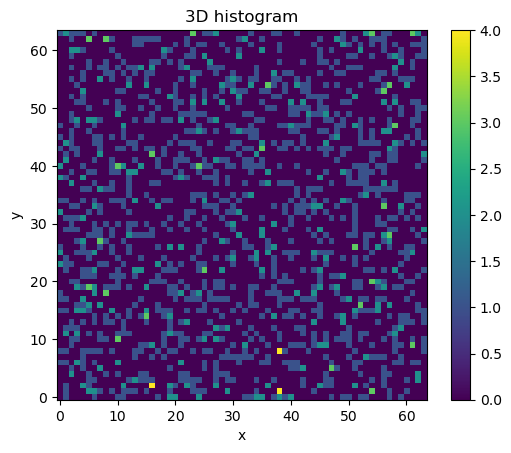

In [6]:
#funzione di numpy che fa histogrammi multidimensionali 
plt.imshow(grid[:,:,0], origin='lower', interpolation='nearest')
plt.colorbar()
plt.title('3D histogram')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [8]:
#quello che abbiamo fatto è un interpolazione più semplice che si puo fare quella che associa al valore del pixel + 1 se una galassia cade entro il pixel 
#questa è la densità ma non ci serve a noi serve rho media

rho_mean = N/L**3
#il numero di galassie medio che cascherebbe ing ongi cella
#volume della cella
cell_volume = (L/n)**3
#compute density contrast
delta = (grid- rho_mean* cell_volume)/(rho_mean* cell_volume)


In [11]:
np.mean(delta), rho_mean
#torna 0.0 perchè la densità media è 0
#la densità media è 0 perchè la densità media è 0

(np.float64(-1.0299920638612292e-17), 0.0001)

In [12]:
#COmpute de FFT of the contrat density field
delta_k= rfftn(delta)


In [ ]:
#dimensioni che ha 
delta_k.shape
#la seconda dimezzata non ha bisogno dei k negativi perchè f(-k) = - f(k)

(64, 64, 33)

In [21]:
kF= 2*np.pi/L
#kF è la frequenza fondamentale che è 2pi/L
#ora ci servono i valori dei k associati quindi metto in gioco fftreq
kx= fftfreq(n, d=1/n)*kF
ky= fftfreq(n, d=1/n)*kF
kz= rfftfreq(n, d=1/n)*kF
#così so che vanno in multipli di frequenza fondamentale 


In [19]:
kx

array([ 0.        ,  0.00628319,  0.01256637,  0.01884956,  0.02513274,
        0.03141593,  0.03769911,  0.0439823 ,  0.05026548,  0.05654867,
        0.06283185,  0.06911504,  0.07539822,  0.08168141,  0.08796459,
        0.09424778,  0.10053096,  0.10681415,  0.11309734,  0.11938052,
        0.12566371,  0.13194689,  0.13823008,  0.14451326,  0.15079645,
        0.15707963,  0.16336282,  0.169646  ,  0.17592919,  0.18221237,
        0.18849556,  0.19477874, -0.20106193, -0.19477874, -0.18849556,
       -0.18221237, -0.17592919, -0.169646  , -0.16336282, -0.15707963,
       -0.15079645, -0.14451326, -0.13823008, -0.13194689, -0.12566371,
       -0.11938052, -0.11309734, -0.10681415, -0.10053096, -0.09424778,
       -0.08796459, -0.08168141, -0.07539822, -0.06911504, -0.06283185,
       -0.05654867, -0.05026548, -0.0439823 , -0.03769911, -0.03141593,
       -0.02513274, -0.01884956, -0.01256637, -0.00628319])

In [17]:
#sono dei numeri un pò a caso
kz

array([0.      , 0.015625, 0.03125 , 0.046875, 0.0625  , 0.078125,
       0.09375 , 0.109375, 0.125   , 0.140625, 0.15625 , 0.171875,
       0.1875  , 0.203125, 0.21875 , 0.234375, 0.25    , 0.265625,
       0.28125 , 0.296875, 0.3125  , 0.328125, 0.34375 , 0.359375,
       0.375   , 0.390625, 0.40625 , 0.421875, 0.4375  , 0.453125,
       0.46875 , 0.484375, 0.5     ])

In [ ]:
#guardo come sono ordinati dalla libreria numpy  dè l'inverso della freq di neiquist
#mentre l'altro è solo la metà +1 di questo array 
#ma fftfreq prende ancehe altre cose in ingresso 

In [22]:
#per avere le coordinate di k in 3D
KX, KY, KZ = np.meshgrid(kx, ky, kz)

In [23]:
KK= np.sqrt(KX**2+KY**2 + KZ**2)


In [24]:
delta_k

array([[[ 3.18323146e-12   +0.j        , -1.34760493e+02  +32.85877487j,
          2.05383506e+02  +34.66684441j, ...,
          8.18248160e+02 +452.98590772j, -3.89518921e+01 -667.92820689j,
         -4.71859200e+01   +0.j        ],
        [-4.08411130e+02 +251.99906931j,  6.46097226e+02 +497.37879337j,
          3.18524332e+02 -150.13239521j, ...,
          5.19308571e+02 -608.85423317j, -2.28419483e+02 +400.55993524j,
         -2.92549087e+02 +703.24343723j],
        [ 4.78000731e+02+1117.20352507j,  1.78742353e+02  -16.90332064j,
         -1.24107894e+03+1472.33571948j, ...,
         -4.79904090e+02 +948.66235593j, -1.85838582e+02 +365.35840706j,
          5.98917374e+02 +375.48179117j],
        ...,
        [-2.21882989e+02 +681.80689239j, -2.85286221e+02 +391.60048551j,
          1.85455279e+02 +236.27301278j, ...,
         -1.23232297e+01  -66.55810279j, -5.49634258e+02 -211.25151424j,
         -2.61348141e+02  -94.93557589j],
        [ 4.78000731e+02-1117.20352507j,  1.1924244

In [ ]:
#per ottenere il ps faccio la correlazione dei due campi nello spazio di fourier che nel caso della psi un integrale diventa un prodotto

In [28]:
pk_grid= delta_k*delta_k.conjugate()

In [ ]:
#plot della k.flatten e la griglia

plt.plot(KK.flatten(), pk_grid.flatten())

In [29]:
kN=np.sqrt(2*np.pi)*n/L

In [ ]:
#perchè non va copilot???

In [ ]:
kF,kN
n_bins_k= 20
k_edges=np.linspace(kF,kN, n_bins_k+1)
#voglio seleizonare quelli che hanno k simile
#faccio un ciclo tra i vari k
for i in range(n_bins_k):
    k_min= k_edges[i]
    k_max= k_edges[i+1]

    mask= (KK.flatten()>= k_min )&(KK.flatten()< k_max)
    pk= np.mean(pk_grid.flatten())
    

In [ ]:
k_centers = 0.5 * (k_edges[:-1] + k_edges[1:])